# Fractional Laplacian Diffusion

This notebook generates `fig:gradflow-fractional-laplacian-diffusion`.  It compares the classical heat equation
$$
    \partial_t \rho_t = -(-\Delta)\rho_t
$$
with two fractional heat equations
$$
    \partial_t \rho_t = -(-\Delta)^{s/2}\rho_t,
    \qquad 0<s<2.
$$
The initial density is a normalized mixture of two localized indicator functions.  The computation uses the exact Fourier multiplier
$$
    \widehat \rho_t(k)=e^{-t|k|^s}\widehat \rho_0(k)
$$
on a large periodic interval, so the figure is lightweight and deterministic.  Smaller values of $s$ make the diffusion increasingly nonlocal and produce heavier tails.

In [1]:
from pathlib import Path
import os
import sys

os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/mpl-ot4ml")

import matplotlib.pyplot as plt
import numpy as np

ROOT = Path.cwd()
if ROOT.name == "notebooks-figures":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "notebooks-figures"))

from figure_style import BLUE, RED, VIOLET, box_axes, figure_dir, interp_color, save_pdf, setup_matplotlib

setup_matplotlib()

NAME = "gradflow-fractional-laplacian-diffusion"
OUT = figure_dir(NAME)
THUMB_DIR = ROOT / "notebooks-figures" / "thumbnails"
THUMB_DIR.mkdir(parents=True, exist_ok=True)

## Spectral evolution

On the periodic interval, the operator $-(-\Delta)^{s/2}$ is diagonal in the Fourier basis.  We use a wide enough computational box so that the displayed window does not feel periodic over the selected times.  The three panels use the same initial density and the same color/time schedule.

In [2]:
# Periodic computational domain. The displayed window is much smaller, which
# keeps the fractional tails visible while avoiding wrap-around artifacts.
L = 48.0
n = 8192
x = np.linspace(-L / 2, L / 2, n, endpoint=False)
dx = x[1] - x[0]

# A mixture of two separated localized indicators with unequal widths and
# weights. The gap makes the immediate nonlocal leakage easy to read.
rho0 = (
    1.00 * (np.abs(x + 1.65) <= 0.40)
    + 0.78 * (np.abs(x - 1.35) <= 0.32)
).astype(float)
rho0 /= np.sum(rho0) * dx

freq = 2.0 * np.pi * np.fft.fftfreq(n, d=dx)
rho0_hat = np.fft.fft(rho0)

def fractional_heat_curves(s, times):
    curves = []
    multiplier_power = np.abs(freq) ** s
    for t in times:
        rho = np.real(np.fft.ifft(np.exp(-t * multiplier_power) * rho0_hat))
        rho = np.maximum(rho, 0.0)
        rho /= np.sum(rho) * dx
        curves.append(rho)
    return curves

# The time grid is deliberately front-loaded to reveal the onset of smoothing,
# while the final time is long enough for fractional tails to separate visually
# from the compact initial support.
times = np.array([0.0, 0.014, 0.050, 0.145, 0.42, 1.15])
models = [
    (2.0, "classical"),
    (0.85, "nonlocal-medium"),
    (0.35, "nonlocal-strong"),
]
curves_by_model = [(s, fname, fractional_heat_curves(s, times)) for s, fname in models]

## Exported panels

The PDF panels contain no embedded title.  LaTeX supplies the panel labels and the caption.  The y-axis scale is shared to make the stronger long-range leakage for small $s$ visible rather than hidden by rescaling.

In [3]:
ymax = 1.06 * max(rho0)
window = (-6.2, 6.2)
mask_window = (x >= window[0]) & (x <= window[1])

def draw_family(ax, curves):
    for k, rho in enumerate(curves):
        color = interp_color(k / (len(curves) - 1), RED, BLUE)
        lw = 1.28 if k == len(curves) - 1 else (1.10 if k > 0 else 1.18)
        ax.plot(x[mask_window], rho[mask_window], color=color, lw=lw, solid_capstyle="round")
        ax.fill_between(x[mask_window], 0, rho[mask_window], color=color, alpha=0.040 if k > 0 else 0.055)
    ax.set_xlim(*window)
    ax.set_ylim(0, ymax)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.tick_params(labelsize=7, pad=1.5)
    ax.set_yticks([])
    ax.set_xticks([-5, 0, 5])
    ax.axhline(0, color="#666666", lw=0.35, alpha=0.55, zorder=0)
    box_axes(ax)

for _, fname, curves in curves_by_model:
    fig, ax = plt.subplots(figsize=(3.05, 1.62))
    draw_family(ax, curves)
    save_pdf(fig, OUT / f"{fname}.pdf", pad_inches=0.035)
    plt.close(fig)

# Compact thumbnail for the GitHub/gallery display.
fig, axes = plt.subplots(1, 3, figsize=(7.7, 1.95))
for ax, (_, _, curves) in zip(axes, curves_by_model):
    draw_family(ax, curves)
fig.subplots_adjust(left=0.025, right=0.995, bottom=0.18, top=0.965, wspace=0.18)
fig.savefig(THUMB_DIR / f"{NAME}.png", dpi=190)
plt.close(fig)

## Figure preview

The output below embeds the generated thumbnail so the figure renders directly on GitHub.

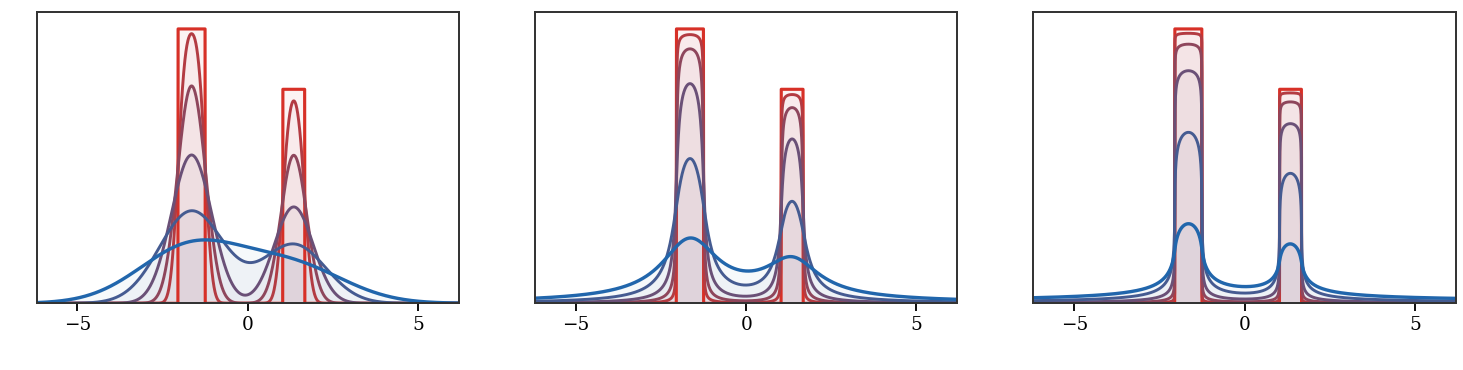

In [4]:
from IPython.display import Image, display

_thumb = Path("thumbnails") / f"{NAME}.png"
if not _thumb.exists():
    _thumb = ROOT / "notebooks-figures" / "thumbnails" / f"{NAME}.png"
display(Image(filename=str(_thumb)))